# Lead Conversion Prediction
## ExtraaLearn EdTech Dataset

**Objective:**
ExtraaLearn is an EdTech startup that generates leads through multiple
channels. Not all leads convert to paying customers. This project builds
a classification model to identify which leads are most likely to convert
and understand the factors driving that conversion.

**ML Problem Type:** Binary Classification
**Target Variable:** `status` (1 = Converted, 0 = Not Converted)
**Primary Metric:** Recall — minimizing missed conversions is the priority

**Project Framework:** 13-step end-to-end data science workflow
Step 1 — Business Problem Definition
Step 2 — Data Understanding
Step 3 — Data Preparation + Cleaning
Step 4 — Exploratory Data Analysis
Step 5/6 — Hypothesis and Statistical Testing
Step 7 — Feature Engineering
Step 8 — Preprocessing for Modeling
Step 9/10/11/12 — Model Building, Evaluation, Tuning and Selection
Step 13 — Feature Importance and Business Recommendations

## Step 1 — Business Problem Definition
---
#### Cost of Each Mistake

**False Negative** — Model predicts *not converted*, lead actually converts.
A real customer is ignored by the sales team. Revenue is lost.
**This is the expensive mistake.**

**False Positive** — Model predicts *converted*, lead does not convert.
Sales team contacts a dead lead. Time is wasted.
This is the acceptable mistake — a sales call costs far less than a lost customer.

**Conclusion:** Optimize for **Recall** — catch as many real conversions as possible,
even at the cost of some false positives.

## Step 2 — Data Understanding
---
##### Data Loading and Initial Inspection
---
### Class Imbalance Observation

- 70% not converted (0), 30% converted (1)
- Dataset is imbalanced
- A model predicting "not converted" for all leads achieves 70% accuracy
  but identifies zero actual conversions
- Accuracy is therefore a misleading metric for this problem
- Recall is the primary metric — it directly measures how many real
  conversions the model correctly identifies
- class_weight='balanced' will be applied during modeling to compensate

In [2]:
# Step 1: Import libraries needed for this project

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hide warning messages so the output stays clean
warnings.filterwarnings("ignore")

# Show all columns when printing a DataFrame
pd.set_option("display.max_columns", None)

# Show up to 200 rows when printing a DataFrame
pd.set_option("display.max_rows", 200)

# Show numbers with 4 decimal places
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Load the dataset from the local file path
file_path = "/Users/nirmal.nustudioz/Documents/machine_learning_data_science_portfolio/datasets/Extraa_Learn.csv"

# Read the CSV file into a DataFrame
data_raw = pd.read_csv(file_path)

# Make a copy to preserve the original data
data = data_raw.copy()

# Print the number of rows and columns
print("Shape:", data.shape)

Shape: (4612, 15)


In [4]:
# Print column names and data types
print(data.dtypes)

ID                           str
age                        int64
current_occupation           str
first_interaction            str
profile_completed            str
website_visits             int64
time_spent_on_website      int64
page_views_per_visit     float64
last_activity                str
print_media_type1            str
print_media_type2            str
digital_media                str
educational_channels         str
referral                     str
status                     int64
dtype: object


In [6]:
# Print the first 5 rows to see what the data looks like
display(data.head())

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.8610,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.3200,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.0740,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.0570,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.9140,Email Activity,No,No,No,No,No,0


In [8]:
# Display a statistical summary of all numerical columns
data.describe()

,age,website_visits,time_spent_on_website,page_views_per_visit,status
count,4612.0000,4612.0000,4612.0000,4612.0000,4612.0000
mean,46.2012,3.5668,724.0113,3.0261,0.2986
std,13.1615,2.8291,743.8287,1.9681,0.4577
min,18.0000,0.0000,0.0000,0.0000,0.0000
25%,36.0000,2.0000,148.7500,2.0777,0.0000
50%,51.0000,3.0000,376.0000,2.7920,0.0000
75%,57.0000,5.0000,1336.7500,3.7562,1.0000
max,63.0000,30.0000,2537.0000,18.4340,1.0000


In [9]:
# Check for missing values in each column
print(data.isnull().sum())

ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64


In [10]:
# Check for duplicate rows
print(data.duplicated().sum())

0


In [11]:
# Check the distribution of the target variable
print(data['status'].value_counts())
print()
print(data['status'].value_counts(normalize=True))

status
0    3235
1    1377
Name: count, dtype: int64

status
0   0.7014
1   0.2986
Name: proportion, dtype: float64


## Step 3 —  Data Preparation + Cleaning
---
### Data Understanding Summary

**Numerical columns:** age, website_visits, time_spent_on_website, page_views_per_visit
**Categorical columns:** current_occupation, first_interaction, profile_completed,
last_activity, print_media_type1, print_media_type2, digital_media,
educational_channels, referral
**Target variable:** status (0 = Not Converted, 1 = Converted)
**ID column:** identifier only — will be dropped before modeling

**Key observations:**
- No missing values
- No duplicate rows
- Dataset is imbalanced — 70% not converted, 30% converted
- profile_completed is ordinal — Low < Medium < High
- website_visits behaves as discrete — count variable
- All categorical columns have clean, consistent values
### Data Cleaning Summary

- ID column dropped — identifier, not a feature
- No missing values to handle
- No duplicates to remove
- No data type corrections needed
- Dataset ready for EDA

In [12]:
# Check unique values for each categorical column
categorical_cols = ['current_occupation', 'first_interaction', 'profile_completed',
                    'last_activity', 'print_media_type1', 'print_media_type2',
                    'digital_media', 'educational_channels', 'referral']

for col in categorical_cols:
    print(col, ":", data[col].unique())
    print()

current_occupation : <StringArray>
['Unemployed', 'Professional', 'Student']
Length: 3, dtype: str

first_interaction : <StringArray>
['Website', 'Mobile App']
Length: 2, dtype: str

profile_completed : <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

last_activity : <StringArray>
['Website Activity', 'Email Activity', 'Phone Activity']
Length: 3, dtype: str

print_media_type1 : <StringArray>
['Yes', 'No']
Length: 2, dtype: str

print_media_type2 : <StringArray>
['No', 'Yes']
Length: 2, dtype: str

digital_media : <StringArray>
['Yes', 'No']
Length: 2, dtype: str

educational_channels : <StringArray>
['No', 'Yes']
Length: 2, dtype: str

referral : <StringArray>
['No', 'Yes']
Length: 2, dtype: str



In [13]:
# Check unique value counts for numerical columns
numerical_cols = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']

for col in numerical_cols:
    print(col, "— unique values:", data[col].nunique())

age — unique values: 46
website_visits — unique values: 27
time_spent_on_website — unique values: 1623
page_views_per_visit — unique values: 2414


In [14]:
# Drop the ID column — it is an identifier, not a feature
data = data.drop(columns=['ID'])

# Confirm the column has been removed
print(data.shape)
print(data.columns.tolist())

(4612, 14)
['age', 'current_occupation', 'first_interaction', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status']


## Step 4 — Exploratory Data Analysis

<p> Exploring relationships between features and the target variable. <br>
Goal: identify which features visually appear to separate converted
from not converted leads. </P>

---
### EDA Summary

**Numerical features:**
- time_spent_on_website is the strongest numerical predictor —
  converted leads spend more time, correlation 0.30 with status
- age has weak correlation (0.12) — distributions overlap heavily
  between converted and not converted
- website_visits and page_views_per_visit are largely independent
  of each other despite measuring related behaviors
- All numerical features are independent of each other —
  no multicollinearity concerns

**Categorical features:**
- first_interaction: Website converts at ~45% vs Mobile App at ~10% —
  strong signal
- profile_completed: High converts most, Low converts least —
  ordinal pattern confirmed
- referral: Yes converts at ~65% vs No at ~29% — strongest
  categorical signal
- current_occupation: Professionals convert most, Students least
- last_activity: Website Activity converts most
- print_media_type1, print_media_type2, digital_media,
  educational_channels: conversion rates close to overall 30% baseline
  — weak signals

**Candidate features for hypothesis testing:**
- Strong: time_spent_on_website, first_interaction,
  profile_completed, referral, current_occupation
- Weak: print_media_type1, print_media_type2, digital_media,
  educational_channels, website_visits, age, page_views_per_visit

**Feature engineering note:**
- profile_completed requires ordinal encoding — Low=0, Medium=1, High=2
- print_media_type1, print_media_type2, digital_media may be combined
  into a single channel feature — evaluate in Step 7

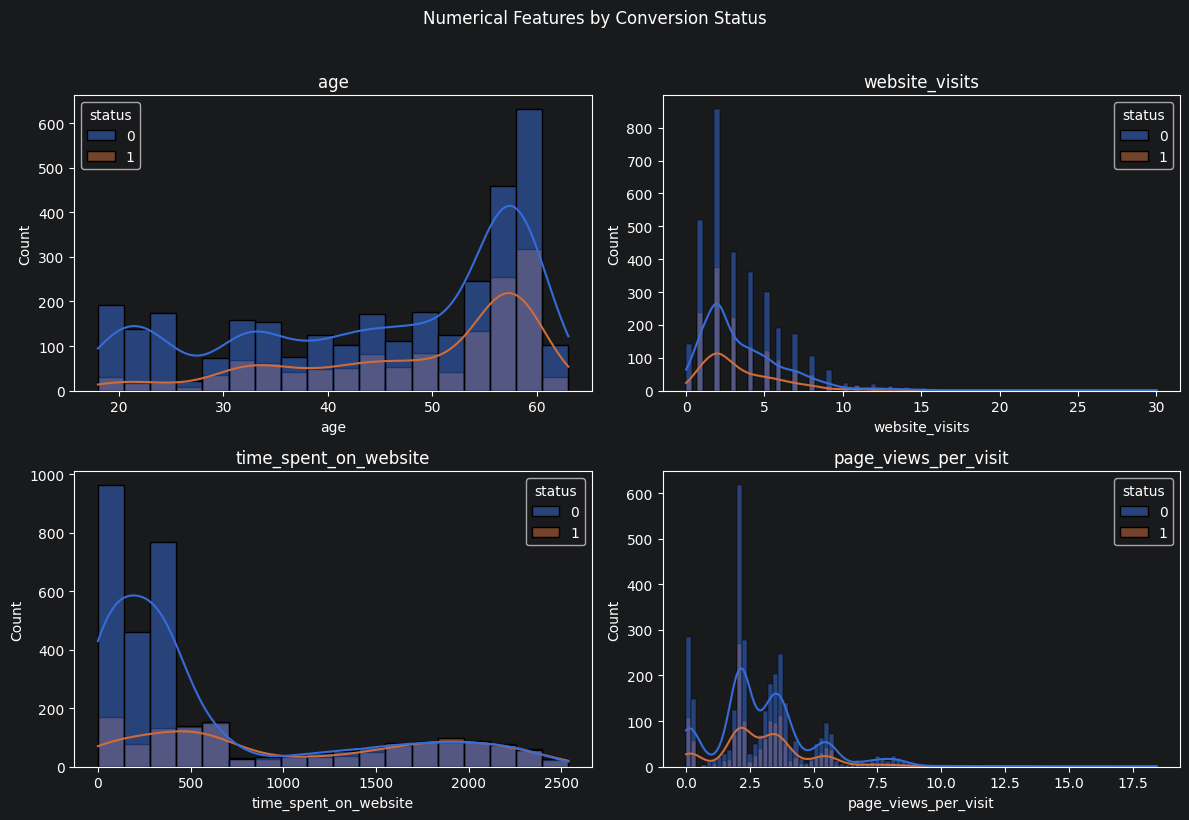

In [15]:
# Plot distribution of each numerical feature split by conversion status
numerical_cols = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=data, x=col, hue='status', kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Numerical Features by Conversion Status", y=1.02)
plt.tight_layout()
plt.show()

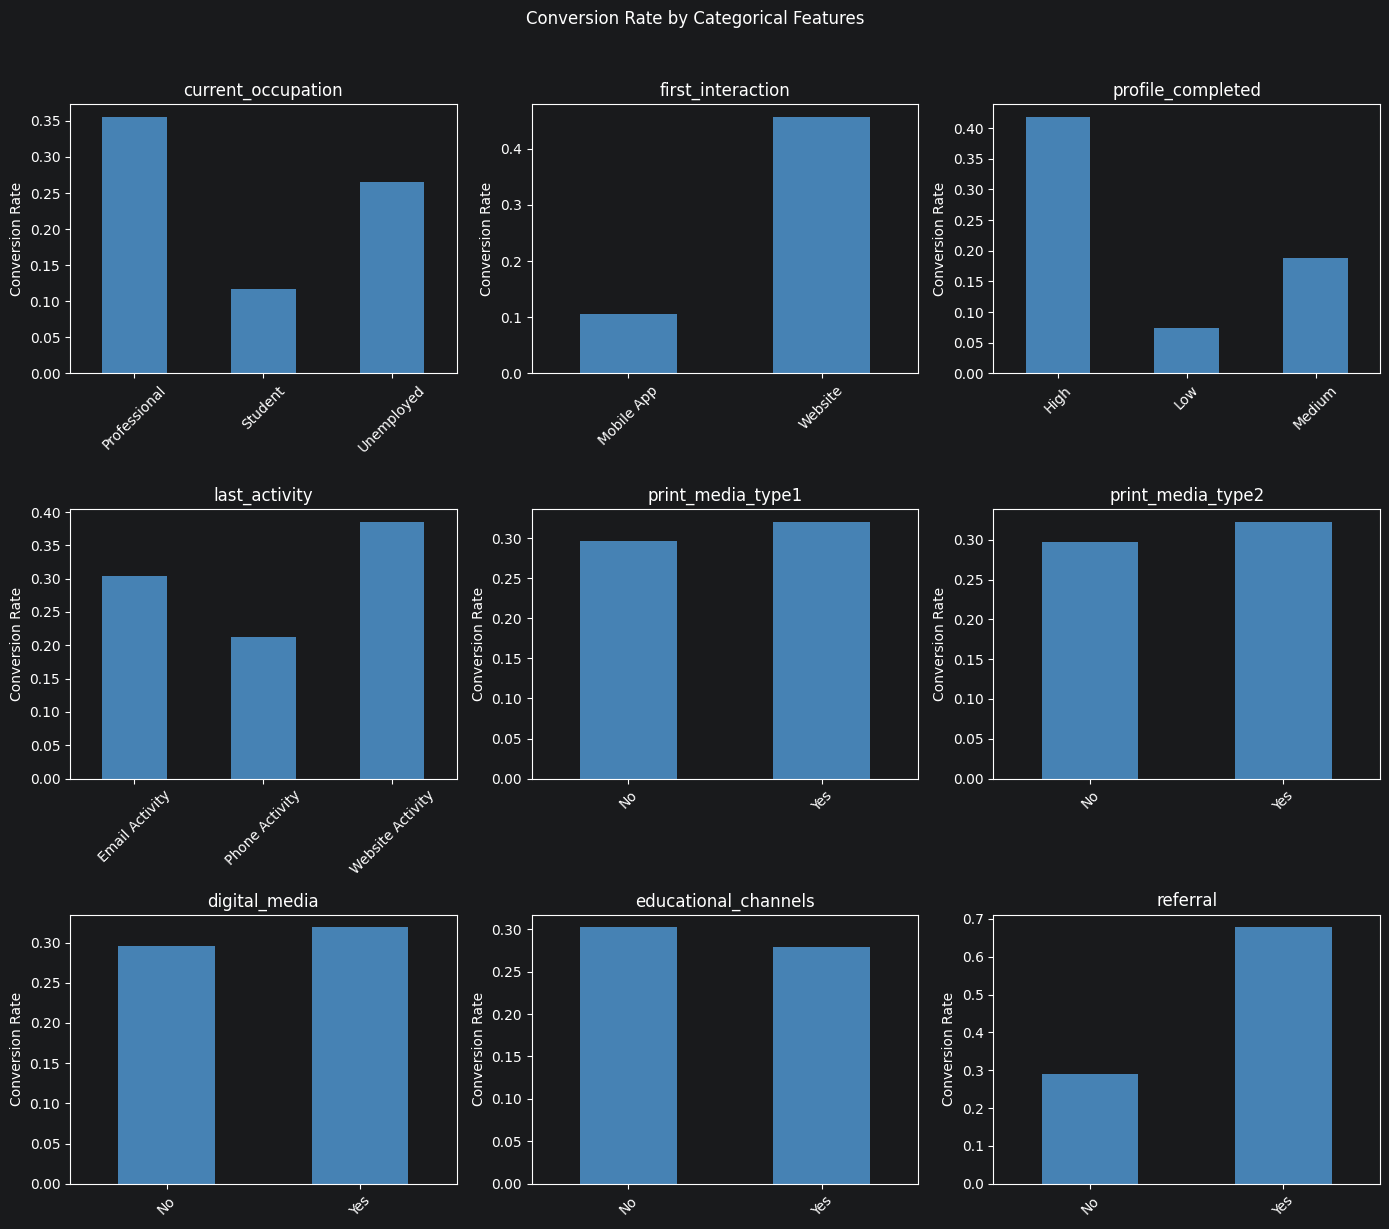

In [16]:
    # Plot conversion rate for each categorical feature
categorical_cols = ['current_occupation', 'first_interaction', 'profile_completed',
                    'last_activity', 'print_media_type1', 'print_media_type2',
                    'digital_media', 'educational_channels', 'referral']

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    conversion_rate = data.groupby(col)['status'].mean()
    conversion_rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel("Conversion Rate")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Conversion Rate by Categorical Features", y=1.02)
plt.tight_layout()
plt.show()

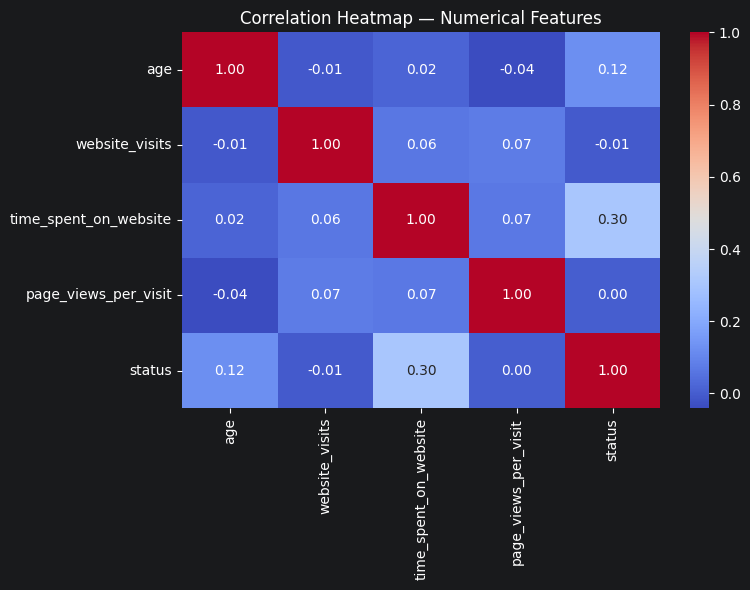

In [17]:
# Plot correlation heatmap for numerical features
plt.figure(figsize=(8, 6))

numerical_cols = ['age', 'website_visits', 'time_spent_on_website',
                  'page_views_per_visit', 'status']

sns.heatmap(data[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()

## Step 5/6 — Hypothesis and Stastical Testing

Testing whether the relationships observed in EDA are statistically
significant or could have occurred by random chance.

- Categorical features → Chi-Square Test
- Continuous features → Independent Samples T-Test

Significance level: α = 0.05

----
### Hypothesis Testing Summary

**T-Tests — Continuous Features:**

| Feature | t-statistic | p-value | Decision |
|---|---|---|---|
| age | 8.3516 | 0.0000 | Reject H0 |
| website_visits | -0.4487 | 0.6536 | Fail to reject H0 |
| time_spent_on_website | 21.5170 | 0.0000 | Reject H0 |
| page_views_per_visit | 0.0208 | 0.9834 | Fail to reject H0 |

**Chi-Square Tests — Categorical Features:**

| Feature | chi2-statistic | p-value | Decision |
|---|---|---|---|
| current_occupation | 134.5990 | 0.0000 | Reject H0 |
| first_interaction | 668.0814 | 0.0000 | Reject H0 |
| profile_completed | 308.4293 | 0.0000 | Reject H0 |
| last_activity | 82.0879 | 0.0000 | Reject H0 |
| print_media_type1 | 1.1009 | 0.2941 | Fail to reject H0 |
| print_media_type2 | 0.5253 | 0.4686 | Fail to reject H0 |
| digital_media | 1.0547 | 0.3044 | Fail to reject H0 |
| educational_channels | 1.3493 | 0.2454 | Fail to reject H0 |
| referral | 63.2151 | 0.0000 | Reject H0 |

**Features with statistically significant relationship with status:** <br>
age, time_spent_on_website, current_occupation, first_interaction,
profile_completed, last_activity, referral

**Features with no statistically significant relationship with status:** <br>
website_visits, page_views_per_visit, print_media_type1,
print_media_type2, digital_media, educational_channels

**Note:** Statistically insignificant features will be excluded
from modeling. This decision is justified by hypothesis testing,
not assumption.

### Part A — T-Tests for Continuous Features

In [18]:
from scipy.stats import ttest_ind

# List of continuous features to test
continuous_features = ['age', 'website_visits',
                       'time_spent_on_website', 'page_views_per_visit']

# Split data into two groups based on conversion status
converted = data[data['status'] == 1]
not_converted = data[data['status'] == 0]

# Run t-test for each feature
for feature in continuous_features:
    t_stat, p_value = ttest_ind(converted[feature], not_converted[feature])

    print(f"Feature: {feature}")
    print(f"  t-statistic : {t_stat:.4f}")
    print(f"  p-value     : {p_value:.4f}")

    if p_value < 0.05:
        print(f"  Decision    : Reject H0 — significant relationship with status")
    else:
        print(f"  Decision    : Fail to reject H0 — no significant relationship")
    print()

Feature: age
  t-statistic : 8.3516
  p-value     : 0.0000
  Decision    : Reject H0 — significant relationship with status

Feature: website_visits
  t-statistic : -0.4487
  p-value     : 0.6536
  Decision    : Fail to reject H0 — no significant relationship

Feature: time_spent_on_website
  t-statistic : 21.5170
  p-value     : 0.0000
  Decision    : Reject H0 — significant relationship with status

Feature: page_views_per_visit
  t-statistic : 0.0208
  p-value     : 0.9834
  Decision    : Fail to reject H0 — no significant relationship



### Part B — Chi-Square Tests for Categorical Features

In [19]:
from scipy.stats import chi2_contingency

# List of categorical features to test
categorical_features = ['current_occupation', 'first_interaction',
                        'profile_completed', 'last_activity',
                        'print_media_type1', 'print_media_type2',
                        'digital_media', 'educational_channels', 'referral']

# Run chi-square test for each feature
for feature in categorical_features:

    # Build contingency table — counts of each category vs status
    contingency_table = pd.crosstab(data[feature], data['status'])

    # Run chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"Feature: {feature}")
    print(f"  chi2-statistic : {chi2:.4f}")
    print(f"  p-value        : {p_value:.4f}")

    if p_value < 0.05:
        print(f"  Decision       : Reject H0 — significant relationship with status")
    else:
        print(f"  Decision       : Fail to reject H0 — no significant relationship")
    print()

Feature: current_occupation
  chi2-statistic : 134.5990
  p-value        : 0.0000
  Decision       : Reject H0 — significant relationship with status

Feature: first_interaction
  chi2-statistic : 668.0814
  p-value        : 0.0000
  Decision       : Reject H0 — significant relationship with status

Feature: profile_completed
  chi2-statistic : 308.4293
  p-value        : 0.0000
  Decision       : Reject H0 — significant relationship with status

Feature: last_activity
  chi2-statistic : 82.0879
  p-value        : 0.0000
  Decision       : Reject H0 — significant relationship with status

Feature: print_media_type1
  chi2-statistic : 1.1009
  p-value        : 0.2941
  Decision       : Fail to reject H0 — no significant relationship

Feature: print_media_type2
  chi2-statistic : 0.5253
  p-value        : 0.4686
  Decision       : Fail to reject H0 — no significant relationship

Feature: digital_media
  chi2-statistic : 1.0547
  p-value        : 0.3044
  Decision       : Fail to reject H

## Step 7 — Feature Engineering
---

### Feature Engineering Summary

**Dropped features — no statistical significance:**
website_visits, page_views_per_visit, print_media_type1,
print_media_type2, digital_media, educational_channels

**Ordinal encoding — profile_completed:**
Low=0, Medium=1, High=2

**One-hot encoding — drop_first=True:**
- current_occupation → Student, Unemployed (Professional dropped)
- first_interaction → Website (Mobile App dropped)
- last_activity → Phone Activity, Website Activity (Email Activity dropped)
- referral → Yes (No dropped)

**Final feature set — 9 features + 1 target:**
age, profile_completed, time_spent_on_website,
current_occupation_Student, current_occupation_Unemployed,
first_interaction_Website, last_activity_Phone Activity,
last_activity_Website Activity, referral_Yes

In [20]:
# Drop features with no statistically significant relationship with status
cols_to_drop = ['website_visits', 'page_views_per_visit',
                'print_media_type1', 'print_media_type2',
                'digital_media', 'educational_channels']

data = data.drop(columns=cols_to_drop)

# Confirm remaining columns
print("Remaining columns:", data.columns.tolist())
print("Shape:", data.shape)

Remaining columns: ['age', 'current_occupation', 'first_interaction', 'profile_completed', 'time_spent_on_website', 'last_activity', 'referral', 'status']
Shape: (4612, 8)


In [21]:
# Ordinal encoding for profile_completed
# Low = 0, Medium = 1, High = 2
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}

data['profile_completed'] = data['profile_completed'].map(ordinal_map)

# Confirm encoding
print(data['profile_completed'].value_counts())

profile_completed
2    2264
1    2241
0     107
Name: count, dtype: int64


In [22]:
# One-hot encoding for remaining categorical features
# drop_first=True drops one column per feature to avoid multicollinearity
data = pd.get_dummies(data,
                      columns=['current_occupation', 'first_interaction',
                               'last_activity', 'referral'],
                      drop_first=True)

# Confirm result
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())

Shape: (4612, 10)
Columns: ['age', 'profile_completed', 'time_spent_on_website', 'status', 'current_occupation_Student', 'current_occupation_Unemployed', 'first_interaction_Website', 'last_activity_Phone Activity', 'last_activity_Website Activity', 'referral_Yes']


## Step 8 — Preprocessing for Modeling

### Train/Test Split

Splitting data into training and test sets before any modeling.
- Training set: model learns from this
- Test set: locked away, used only for final evaluation
- Stratified split: preserves 70/30 class distribution in both sets

---

### Preprocessing Summary

- Features separated from target: X and y
- Train/Test split: 70% train (3,228 records), 30% test (1,384 records)
- Stratified split: class distribution preserved in both sets
- Scaling applied for Logistic Regression only:
  - Scaler fitted on training data only — prevents data leakage
  - Same scaler used to transform test data
- Decision Tree and Random Forest use unscaled X_train and X_test
- Logistic Regression uses X_train_scaled and X_test_scaled

In [23]:
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = data.drop(columns=['status'])
y = data['status']

# Split into training and test sets
# test_size=0.30 means 30% goes to test
# stratify=y preserves class distribution in both sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.30,
                                                      stratify=y,
                                                      random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print()
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print()
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (3228, 9)
X_test shape: (1384, 9)

y_train distribution:
status
0   0.7014
1   0.2986
Name: proportion, dtype: float64

y_test distribution:
status
0   0.7016
1   0.2984
Name: proportion, dtype: float64


In [24]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler on training data only
# Then transform both train and test using the same scaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)

Scaling complete.
X_train_scaled shape: (3228, 9)


## Step 9/10/11/12 — Baseline Model + Evaluation + Insights + Tuning + Comparison and Selection

### Logistic Regression
<p> Logistic Regression is the simplest classification model.It serves as the baseline — every subsequent model must beat these results to justify its added complexity. </p>

---
#### Logistic Regression — Baseline Results

| Metric | Score |
|---|---|
| Accuracy | 0.81 |
| Precision (class 1) | 0.63 |
| Recall (class 1) | 0.84 |
| F1 (class 1) | 0.72 |
| AUC | 0.8793 |

**Baseline to beat:** Recall = 0.84

**Key findings from coefficients:**
- first_interaction_Website is the strongest positive driver
- time_spent_on_website and profile_completed follow closely
- Students and unemployed leads are less likely to convert
- Phone activity as last interaction reduces conversion likelihood

In [25]:
from sklearn.linear_model import LogisticRegression

# Build Logistic Regression model
# class_weight='balanced' compensates for 70/30 class imbalance
# max_iter=1000 gives the optimizer enough iterations to converge
# random_state=42 ensures reproducibility
lr_model = LogisticRegression(class_weight='balanced',
                               max_iter=1000,
                               random_state=42)

# Train on scaled training data
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Make predictions on test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Predict probabilities for AUC calculation
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print()

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Print AUC score
print("AUC Score:", round(roc_auc_score(y_test, y_prob_lr), 4))

Confusion Matrix:
[[769 202]
 [ 66 347]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       971
           1       0.63      0.84      0.72       413

    accuracy                           0.81      1384
   macro avg       0.78      0.82      0.79      1384
weighted avg       0.83      0.81      0.81      1384

AUC Score: 0.8793


In [27]:
# Inspect Logistic Regression coefficients
# Shows direction and strength of each feature's effect on conversion
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

# Sort by coefficient value
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print(coef_df)

                          Feature  Coefficient
5       first_interaction_Website       1.1938
2           time_spent_on_website       0.9302
1               profile_completed       0.7977
8                    referral_Yes       0.2756
7  last_activity_Website Activity       0.2384
0                             age       0.1094
4   current_occupation_Unemployed      -0.2281
6    last_activity_Phone Activity      -0.2930
3      current_occupation_Student      -0.4740


### Decision Tree
Building a Decision Tree classifier in two stages:
- Stage A: Baseline unconstrained tree — observe overfitting
- Stage B: Tuned tree using GridSearchCV — fix overfitting
----
#### Stage A: Baseline Decision Tree Results

| Metric | Logistic Regression | Decision Tree (Base) |
|---|---|---|
| Recall (class 1) | 0.84 | 0.69 |
| AUC | 0.8793 | 0.7785 |
| Accuracy | 0.81 | 0.81 |

**Observation:** Unconstrained tree overfits severely.
Train accuracy 99.88% vs test accuracy 81.43% — 18.5 point gap.
Recall drops below baseline. Tuning required.

#### Stage B — Tuned Decision Tree Results

Best parameters: max_depth=3, min_samples_leaf=100,
min_samples_split=10, criterion=gini

| Metric | LR Baseline | DT Base | DT Tuned |
|---|---|---|---|
| Recall (class 1) | 0.84 | 0.69 | 0.90 |
| Precision (class 1) | 0.63 | 0.69 | 0.61 |
| F1 (class 1) | 0.72 | 0.69 | 0.73 |
| AUC | 0.8793 | 0.7785 | 0.8845 |
| Accuracy | 0.81 | 0.81 | 0.80 |
| Train-Test Gap | - | 18.5pts | 0.5pts |

**Key observations:**
- Tuning eliminated overfitting — train/test gap reduced from 18.5 to 0.5 points
- Recall improved from 0.69 to 0.90 — beats baseline of 0.84
- Precision decreased to 0.61 — 38.7% of flagged leads are false alarms
- AUC marginally better than Logistic Regression baseline
- max_depth=3 confirms patterns are driven by a few strong features

#### Stage A — Baseline Decision Tree (Unconstrained)

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Build unconstrained Decision Tree
# No depth limit — tree grows until all leaves are pure
# class_weight='balanced' compensates for class imbalance
dt_base = DecisionTreeClassifier(class_weight='balanced',
                                  random_state=42)

# Train on unscaled training data
dt_base.fit(X_train, y_train)

# Evaluate on training data
y_pred_train_dt = dt_base.predict(X_train)

# Evaluate on test data
y_pred_test_dt = dt_base.predict(X_test)

# Print training accuracy
print("Training Accuracy:", round(dt_base.score(X_train, y_train), 4))

# Print test accuracy
print("Test Accuracy:", round(dt_base.score(X_test, y_test), 4))

Training Accuracy: 0.9988
Test Accuracy: 0.8143


In [29]:
# Full evaluation of baseline Decision Tree on test set
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_dt))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_test_dt))
print("AUC Score:", round(roc_auc_score(y_test,
                          dt_base.predict_proba(X_test)[:, 1]), 4))

Confusion Matrix:
[[843 128]
 [129 284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       971
           1       0.69      0.69      0.69       413

    accuracy                           0.81      1384
   macro avg       0.78      0.78      0.78      1384
weighted avg       0.81      0.81      0.81      1384

AUC Score: 0.7785


#### Stage B — Tuned Decision Tree (GridSearchCV)

In [30]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid_dt = {
    'max_depth': [3, 5, 6, 8, 10],
    'min_samples_leaf': [10, 25, 50, 100],
    'min_samples_split': [10, 25, 50],
    'criterion': ['gini', 'entropy']
}

# Build base Decision Tree for GridSearchCV
dt = DecisionTreeClassifier(class_weight='balanced',
                             random_state=42)

# Set up GridSearchCV
# scoring='recall' optimizes for catching real conversions
# cv=5 runs 5-fold cross validation
# n_jobs=-1 uses all CPU cores
grid_search_dt = GridSearchCV(estimator=dt,
                               param_grid=param_grid_dt,
                               scoring='recall',
                               cv=5,
                               n_jobs=-1,
                               verbose=1)

# Run the search on training data only
grid_search_dt.fit(X_train, y_train)

print("Best parameters:", grid_search_dt.best_params_)
print("Best cross-validated recall:", round(grid_search_dt.best_score_, 4))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 100, 'min_samples_split': 10}
Best cross-validated recall: 0.8921


In [31]:
# Get the best model from GridSearchCV
dt_tuned = grid_search_dt.best_estimator_

# Evaluate on training data
print("Training Accuracy:", round(dt_tuned.score(X_train, y_train), 4))
print()

# Evaluate on test data
y_pred_dt_tuned = dt_tuned.predict(X_test)

print("Test Accuracy:", round(dt_tuned.score(X_test, y_test), 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_tuned))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_tuned))
print("AUC Score:", round(roc_auc_score(y_test,
                          dt_tuned.predict_proba(X_test)[:, 1]), 4))

Training Accuracy: 0.7952

Test Accuracy: 0.8006

Confusion Matrix:
[[737 234]
 [ 42 371]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.76      0.84       971
           1       0.61      0.90      0.73       413

    accuracy                           0.80      1384
   macro avg       0.78      0.83      0.79      1384
weighted avg       0.85      0.80      0.81      1384

AUC Score: 0.8845


### Random Forest

Building a Random Forest classifier in two stages:
- Stage A: Baseline unconstrained forest — observe overfitting
- Stage B: Tuned forest using GridSearchCV — optimize for recall

---
### Stage A — Baseline Random Forest Results

| Metric | LR Baseline | DT Tuned | RF Base |
|---|---|---|---|
| Recall (class 1) | 0.84 | 0.90 | 0.70 |
| Precision (class 1) | 0.63 | 0.61 | 0.74 |
| F1 (class 1) | 0.72 | 0.73 | 0.72 |
| AUC | 0.8793 | 0.8845 | 0.9017 |
| Accuracy | 0.81 | 0.80 | 0.84 |

**Observation:** Base Random Forest has highest AUC of all models so far.
Recall is lower than tuned Decision Tree — tuning required to
optimize for recall while preserving strong discrimination ability.

### Stage B — Tuned Random Forest Results

Best parameters: max_depth=4, max_features=0.9, max_samples=0.7,
min_samples_leaf=50, n_estimators=100

| Metric | LR Baseline | DT Tuned | RF Base | RF Tuned |
|---|---|---|---|---|
| Recall (class 1) | 0.84 | 0.90 | 0.70 | 0.88 |
| Precision (class 1) | 0.63 | 0.61 | 0.74 | 0.64 |
| F1 (class 1) | 0.72 | 0.73 | 0.72 | 0.74 |
| AUC | 0.8793 | 0.8845 | 0.9017 | 0.9142 |
| Accuracy | 0.81 | 0.80 | 0.84 | 0.82 |
| Train-Test Gap | - | 0.5pts | 16pts | 0.33pts |

**Key observations:**
- Tuning reduced train-test gap from 16 points to 0.33 points
- Highest AUC of all models — best class separation
- Recall beats LR baseline — misses 50 real conversions vs 66
- Will outperform DT on larger datasets due to superior
  discrimination ability

#### Stage A — Baseline Random Forest (Unconstrained)

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Build unconstrained Random Forest
# n_estimators=100 builds 100 trees
# class_weight='balanced' compensates for class imbalance
rf_base = RandomForestClassifier(n_estimators=100,
                                  class_weight='balanced',
                                  random_state=42,
                                  n_jobs=-1)

# Train on unscaled training data
rf_base.fit(X_train, y_train)

# Evaluate on training data
print("Training Accuracy:", round(rf_base.score(X_train, y_train), 4))
print()

# Evaluate on test data
y_pred_test_rf = rf_base.predict(X_test)
print("Test Accuracy:", round(rf_base.score(X_test, y_test), 4))

Training Accuracy: 0.9988

Test Accuracy: 0.8382


In [33]:
# Full evaluation of baseline Random Forest on test set
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_rf))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_test_rf))
print("AUC Score:", round(roc_auc_score(y_test,
                          rf_base.predict_proba(X_test)[:, 1]), 4))

Confusion Matrix:
[[872  99]
 [125 288]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       971
           1       0.74      0.70      0.72       413

    accuracy                           0.84      1384
   macro avg       0.81      0.80      0.80      1384
weighted avg       0.84      0.84      0.84      1384

AUC Score: 0.9017


#### Stage B — Tuned Random Forest (GridSearchCV)

In [34]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [10, 25, 50],
    'max_features': [0.5, 0.7, 0.9],
    'max_samples': [0.7, 0.9]
}

# Build base Random Forest for GridSearchCV
rf = RandomForestClassifier(class_weight='balanced',
                             random_state=42,
                             n_jobs=-1)

# Set up GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf,
                               param_grid=param_grid_rf,
                               scoring='recall',
                               cv=5,
                               n_jobs=-1,
                               verbose=1)

# Run the search on training data only
grid_search_rf.fit(X_train, y_train)

print("Best parameters:", grid_search_rf.best_params_)
print("Best cross-validated recall:", round(grid_search_rf.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 4, 'max_features': 0.9, 'max_samples': 0.7, 'min_samples_leaf': 50, 'n_estimators': 100}
Best cross-validated recall: 0.8911


In [35]:
# Get the best model from GridSearchCV
rf_tuned = grid_search_rf.best_estimator_

# Evaluate on training data
print("Training Accuracy:", round(rf_tuned.score(X_train, y_train), 4))
print()

# Evaluate on test data
y_pred_rf_tuned = rf_tuned.predict(X_test)

print("Test Accuracy:", round(rf_tuned.score(X_test, y_test), 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned))
print("AUC Score:", round(roc_auc_score(y_test,
                          rf_tuned.predict_proba(X_test)[:, 1]), 4))

Training Accuracy: 0.8191

Test Accuracy: 0.8158

Confusion Matrix:
[[766 205]
 [ 50 363]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       971
           1       0.64      0.88      0.74       413

    accuracy                           0.82      1384
   macro avg       0.79      0.83      0.80      1384
weighted avg       0.85      0.82      0.82      1384

AUC Score: 0.9142


### Model Comparison and Selection

#### Model Selection — Tuned Random Forest

**Selected Model:** Tuned Random Forest

**Primary metric:** AUC — 0.9142, highest of all models.
If a converted and non-converted lead are randomly selected,
there is a 91.42% chance the model assigns a higher probability
to the converted lead.

**Recall:** 0.88 — beats the Logistic Regression baseline of 0.84.
The model correctly identifies 88% of all actual conversions.

**Tradeoff accepted:**
- Recall (0.88) is slightly lower than tuned Decision Tree (0.90)
- FN is 50 vs 42 for tuned Decision Tree
- This tradeoff is accepted because RF's superior AUC indicates
  better generalization to new data and larger datasets

**Why not Decision Tree:**
- DT recall of 0.90 is marginally better on this sample
- DT AUC of 0.8845 is weaker — less reliable on unseen data
- RF will consistently outperform DT as dataset grows

**Why not Logistic Regression:**
- LR is the baseline — both tree models outperform it
- LR assumes linear relationships — misses complex interactions
  between features that trees capture

**Speed consideration:**
- RF is slower than DT at prediction time
- For batch scoring use case — speed is not a constraint
- If real-time scoring were required, DT would be reconsidered

In [36]:
# Build a comparison table for all models
comparison = {
    'Model': [
        'Logistic Regression',
        'Decision Tree (Tuned)',
        'Random Forest (Tuned)'
    ],
    'Recall (class 1)': [0.84, 0.90, 0.88],
    'Precision (class 1)': [0.63, 0.61, 0.64],
    'F1 (class 1)': [0.72, 0.73, 0.74],
    'AUC': [0.8793, 0.8845, 0.9142],
    'Accuracy': [0.81, 0.80, 0.82],
    'Train-Test Gap': ['N/A', '0.5pts', '0.33pts']
}

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Model,Recall (class 1),Precision (class 1),F1 (class 1),AUC,Accuracy,Train-Test Gap
0,Logistic Regression,0.8400,0.6300,0.7200,0.8793,0.8100,N/A
1,Decision Tree (Tuned),0.9000,0.6100,0.7300,0.8845,0.8000,0.5pts
2,Random Forest (Tuned),0.8800,0.6400,0.7400,0.9142,0.8200,0.33pts


## Step 13 — Feature Importance and Business Recommendations


### Feature Importance Summary
---
Top 3 features drive 88% of model decisions:
- first_interaction_Website: 34.82%
- time_spent_on_website: 33.11%
- profile_completed: 21.08%

Remaining 6 features share 12% of importance.

**Notable finding — referral_Yes:**
Strong in hypothesis testing (chi2=63.22) and EDA (65% conversion rate)
but near-zero feature importance in the model.
Reason: referred leads also tend to have high profile completion and
website first interaction — the model captures referral's signal
through those stronger features. Statistical significance and
predictive value answer different questions.

**Notable finding — age:**
Correlated with conversion in EDA but only 3% feature importance.
Reason: age is redundant once time_spent_on_website and
profile_completed are available — those features already capture
what age was signaling.


### Business Recommendations

---

**Recommendation 1 — Invest in Mobile App Experience**

Observation: first_interaction_Website is the strongest conversion
driver (34.82% importance). Website leads convert at 45% vs
Mobile App at 10%.

Action: Conduct UX audit of the mobile app to identify conversion
gaps. Prioritize mobile app improvements to match website
conversion experience.

Expected outcome: Closing the mobile-to-website conversion gap
would significantly expand the addressable lead pool.

Follow-up analysis: Break down first_interaction by age group —
determine whether mobile underperformance is a demographic issue
(younger audience converting less) or a UX issue (poor mobile
experience regardless of age).

---

**Recommendation 2 — Optimize Website Content for Quality Over Quantity**

Observation: time_spent_on_website is the second strongest driver
(33.11% importance). Longer time does not always indicate higher
conversion — leads may be spending time searching for clarity.

Action: Audit page-level engagement to identify where leads drop
off or linger without converting. Consolidate key conversion
information to reduce navigation friction — the goal is to
convince the lead on first impression.

Expected outcome: Reducing time-to-decision on the website should
increase conversion rate without requiring more traffic.

Follow-up analysis: Cross-analyze page_views_per_visit with
time_spent_on_website and conversion — identify whether high page
views with high time indicates confusion or genuine engagement.

---

**Recommendation 3 — Reduce Profile Completion Friction**

Observation: profile_completed is the third strongest driver
(21.08% importance). High completion strongly predicts conversion.
Only 107 leads (2.3%) have low completion — but those leads
convert at the lowest rate.

Action: Implement profile pre-population by parsing CV uploads or
integrating with professional platforms (LinkedIn, job boards).
Reduce the manual effort required to complete a profile.

Expected outcome: Moving leads from low to medium/high profile
completion should directly improve their conversion probability.

Follow-up analysis: Segment profile completion by channel and
occupation — determine whether referred leads or professionals
complete profiles at higher rates, and target pre-population
efforts accordingly.

In [37]:
# Get feature importances from tuned Random Forest
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_tuned.feature_importances_
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    'Importance', ascending=False).reset_index(drop=True)

display(feature_importance_df)

,Feature,Importance
0,first_interaction_Website,0.3482
1,time_spent_on_website,0.3311
2,profile_completed,0.2108
3,last_activity_Phone Activity,0.0391
4,age,0.0304
5,last_activity_Website Activity,0.0249
6,current_occupation_Student,0.0081
7,current_occupation_Unemployed,0.0074
8,referral_Yes,0.0000


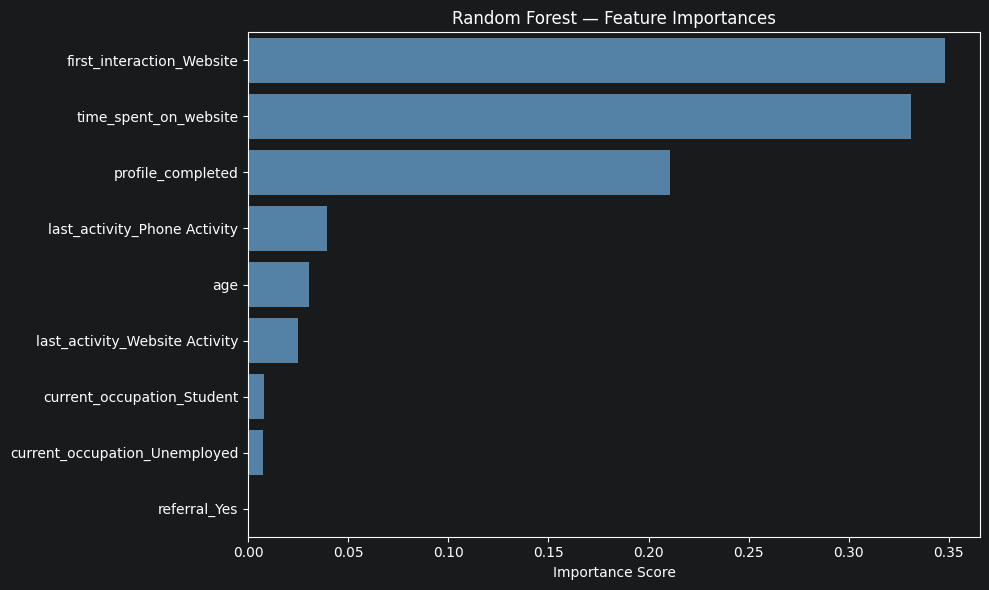

In [38]:
# Plot feature importances
plt.figure(figsize=(10, 6))

sns.barplot(data=feature_importance_df,
            x='Importance',
            y='Feature',
            color='steelblue')

plt.title("Random Forest — Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()